## Q5 V-plot
Q- You can imagine when a protein binds to DNA, then that region will be protected by nucleases (a type of enzyme that cleaves DNA). If you are to plot the protected fragments at protein binding sites, it will take a V-form. Your goal is to show this V-formation using the input data.

X: Difference between two centers. C1 = center using Column3 and Column4, C2 = center using Column9 and Column10. X-coordinate will be C2 - C1

Y: Column10 - Column9

Z: Counter of Y at X. By default Z for Y at X is Zero.

And example is:

-500 65 10

X: -500, Y: 65, and Z: 10, telling that 500 bases relative to protein bound to DNA has 10 fragments of 65 base pair in size.

You have to plot a heatmap of this.

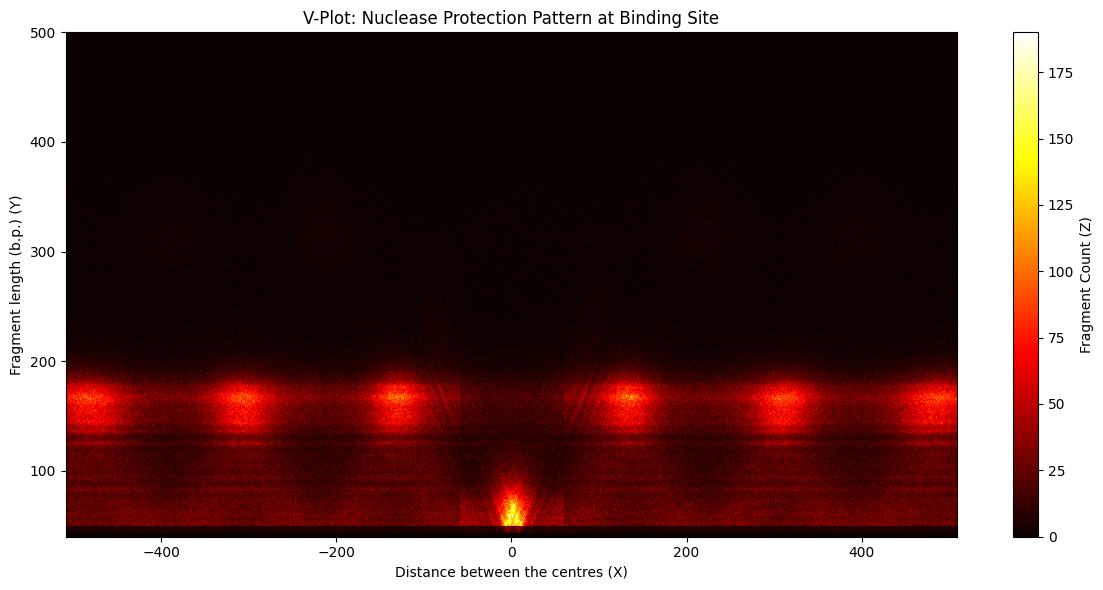

In [3]:
# Importing necessary libraries first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Reading the mapped.bed input file given into a pandas DataFrame for easier plotting
df = pd.read_csv("mapped.bed.gz", sep="\t", header=None)
# Calculating X and Y as instructed in the question
C1 = ((df[2] + df[3]) // 2).astype(int) # centre of binding site
C2 = ((df[8] + df[9]) // 2).astype(int) # centre of fragment
X = C2 - C1  # distance between both the centres
Y = df[9] - df[8] # length of the fragment

# Using defaultdict as taught in tutorial
Z = defaultdict(int)
# Z is a dictionary which will contain the count of each unique pair (X,Y)
for i in range(len(X)):
    Z[(X[i],Y[i])] += 1

# Sorting the X and Y values
x_vals = sorted(set(x for x, _ in Z))
y_vals = sorted(set(y for _, y in Z))

# Creating a matrix which will contain the frequency of each pair(X,Y)
# where X and Y will be in ascending order which is important to show on the heatmap
Z_heatmap = np.zeros((len(y_vals), len(x_vals)))

x_index={}
for i,v in enumerate(x_vals):
    x_index[v]=i
y_index={}
for i,v in enumerate(y_vals):
    y_index[v]=i

for (x, y), count in Z.items():
    Z_heatmap[y_index[y], x_index[x]] = count # We have taken y,x to ensure Y values comes on Y-axis and X values on X-axis

# Plotting
plt.figure(figsize=(12, 6))
plt.imshow(Z_heatmap, aspect='auto', origin='lower',
           extent=[min(x_vals), max(x_vals), min(y_vals), max(y_vals)],
           cmap='hot')
plt.colorbar(label="Fragment Count (Z)")
plt.xlabel("Distance between the centres (X)")
plt.ylabel("Fragment length (b.p.) (Y)")
plt.title("V-Plot: Nuclease Protection Pattern at Binding Site")
plt.tight_layout()
plt.show()

Thus we can see that the heatmap is of V-shaped form due to which it is a V-plot.